# Predicting Student Dropout and Academic Success
## An End-to-End Data Science Project Using CRISP-DM

In [95]:
# Core libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [96]:
from google.colab import files

uploaded = files.upload()

Saving data.csv to data (1).csv


In [98]:
import io

csv_file = next(
    name for name in uploaded.keys()
    if name.lower().endswith(".csv")
)

# sep=None allows pandas to infer comma/semicolon delimiters
df = pd.read_csv(
    io.BytesIO(uploaded[csv_file]),
    sep=None,
    engine="python"
)

print(f"Loaded file: {csv_file}")

Loaded file: data (1).csv


In [99]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (4424, 37)

Columns:
['\ufeffMarital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inf

In [100]:
df.head()

,﻿Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [101]:
df.sample(5, random_state=RANDOM_STATE)

,﻿Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
1255,4,39,1,9130,1,1,133.1,1,3,1,5,5,110.0,1,0,0,1,0,1,30,0,0,6,7,0,0.000000,0,0,6,16,1,10.000000,0,11.1,0.6,2.02,Dropout
3458,1,17,1,9238,1,1,125.0,1,4,3,1,1,119.8,0,0,0,1,0,0,18,0,0,6,9,5,11.571429,0,0,6,8,6,12.142857,0,16.2,0.3,-0.92,Graduate
3390,1,17,1,9853,1,1,133.0,1,38,38,9,9,127.4,0,0,1,1,0,1,18,0,0,7,7,7,12.714286,0,0,7,7,7,12.285714,0,16.2,0.3,-0.92,Graduate
1497,1,17,2,9670,1,1,110.0,1,1,1,4,10,115.3,1,0,0,1,1,0,19,0,0,6,8,6,13.857143,0,0,6,8,5,13.000000,0,15.5,2.8,-4.06,Graduate
1536,1,39,1,9500,1,1,130.0,1,37,19,9,8,106.2,1,0,0,1,0,0,27,0,0,7,14,0,0.000000,0,0,7,14,0,0.000000,0,11.1,0.6,2.02,Dropout


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   ﻿Marital status                                 4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [103]:
target_col = next(
    col for col in df.columns
    if col.strip().lower() == "target"
)

print("Target column:", target_col)

df[target_col].value_counts()

Target column: Target


,count
Target,
Graduate,2209
Dropout,1421
Enrolled,794


In [104]:
target_distribution = pd.DataFrame({
    "Count": df[target_col].value_counts(),
    "Percentage": df[target_col]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
})

target_distribution

,Count,Percentage
Target,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


In [105]:
# Work with the original data without modifying it
df_audit = df.copy()

print("Shape:", df_audit.shape)
print("Number of rows:", df_audit.shape[0])
print("Number of columns:", df_audit.shape[1])

Shape: (4424, 37)
Number of rows: 4424
Number of columns: 37


In [106]:
for i, col in enumerate(df_audit.columns):
    print(i, repr(col))

0 '\ufeffMarital status'
1 'Application mode'
2 'Application order'
3 'Course'
4 'Daytime/evening attendance\t'
5 'Previous qualification'
6 'Previous qualification (grade)'
7 'Nacionality'
8 "Mother's qualification"
9 "Father's qualification"
10 "Mother's occupation"
11 "Father's occupation"
12 'Admission grade'
13 'Displaced'
14 'Educational special needs'
15 'Debtor'
16 'Tuition fees up to date'
17 'Gender'
18 'Scholarship holder'
19 'Age at enrollment'
20 'International'
21 'Curricular units 1st sem (credited)'
22 'Curricular units 1st sem (enrolled)'
23 'Curricular units 1st sem (evaluations)'
24 'Curricular units 1st sem (approved)'
25 'Curricular units 1st sem (grade)'
26 'Curricular units 1st sem (without evaluations)'
27 'Curricular units 2nd sem (credited)'
28 'Curricular units 2nd sem (enrolled)'
29 'Curricular units 2nd sem (evaluations)'
30 'Curricular units 2nd sem (approved)'
31 'Curricular units 2nd sem (grade)'
32 'Curricular units 2nd sem (without evaluations)'
33 'Un

In [107]:
print(col)

Target


In [108]:
column_audit = pd.DataFrame({
    "column": df_audit.columns,
    "leading_space": [c != c.lstrip() for c in df_audit.columns],
    "trailing_space": [c != c.rstrip() for c in df_audit.columns],
    "contains_tab": ["\t" in c for c in df_audit.columns],
    "contains_newline": ["\n" in c for c in df_audit.columns],
    "length": [len(c) for c in df_audit.columns]
})

column_audit[
    column_audit[
        ["leading_space", "trailing_space",
         "contains_tab", "contains_newline"]
    ].any(axis=1)
]

,column,leading_space,trailing_space,contains_tab,contains_newline,length
4,Daytime/evening attendance\t,False,True,True,False,27


In [109]:
missing = pd.DataFrame({
    "Missing Count": df_audit.isnull().sum(),
    "Missing Percentage": (
        df_audit.isnull().mean() * 100
    ).round(2)
})

missing = missing.sort_values(
    "Missing Count",
    ascending=False
)

missing

,Missing Count,Missing Percentage
﻿Marital status,0,0.0
Application mode,0,0.0
Application order,0,0.0
Course,0,0.0
Daytime/evening attendance\t,0,0.0
Previous qualification,0,0.0
Previous qualification (grade),0,0.0
Nacionality,0,0.0
Mother's qualification,0,0.0
Father's qualification,0,0.0


In [110]:
print("Total missing cells:",
      df_audit.isnull().sum().sum())

Total missing cells: 0


In [111]:
hidden_missing_tokens = [
    "", " ", "?", "NA", "N/A",
    "na", "null", "NULL",
    "None", "none", "-"
]

hidden_missing_results = {}

for col in df_audit.columns:
    if df_audit[col].dtype == "object":
        counts = (
            df_audit[col]
            .astype(str)
            .str.strip()
            .isin(hidden_missing_tokens)
            .sum()
        )

        if counts > 0:
            hidden_missing_results[col] = counts

hidden_missing_results

{}

In [112]:
duplicate_count = df_audit.duplicated().sum()

print("Duplicate rows:", duplicate_count)
print(
    "Duplicate percentage:",
    round(100 * duplicate_count / len(df_audit), 2),
    "%"
)

Duplicate rows: 0
Duplicate percentage: 0.0 %


In [113]:
print(df_audit[target_col].unique())
print()

print(df_audit[target_col].value_counts())

['Dropout' 'Graduate' 'Enrolled']

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [114]:
df_audit[target_col].map(repr).value_counts()

,count
Target,
'Graduate',2209
'Dropout',1421
'Enrolled',794


In [115]:
profile = pd.DataFrame({
    "dtype": df_audit.dtypes,
    "unique_values": df_audit.nunique(),
    "missing": df_audit.isnull().sum(),
    "min": df_audit.select_dtypes(include=np.number).min(),
    "max": df_audit.select_dtypes(include=np.number).max()
})

profile

,dtype,unique_values,missing,min,max
Admission grade,float64,620,0,95.00,190.000000
Age at enrollment,int64,46,0,17.00,70.000000
Application mode,int64,18,0,1.00,57.000000
Application order,int64,8,0,0.00,9.000000
Course,int64,17,0,33.00,9991.000000
Curricular units 1st sem (approved),int64,23,0,0.00,26.000000
Curricular units 1st sem (credited),int64,21,0,0.00,20.000000
Curricular units 1st sem (enrolled),int64,23,0,0.00,26.000000
Curricular units 1st sem (evaluations),int64,35,0,0.00,45.000000
Curricular units 1st sem (grade),float64,805,0,0.00,18.875000


In [116]:
for col in df_audit.columns:
    print(
        f"{col:<50} "
        f"dtype={str(df_audit[col].dtype):<10} "
        f"unique={df_audit[col].nunique()}"
    )

﻿Marital status                                    dtype=int64      unique=6
Application mode                                   dtype=int64      unique=18
Application order                                  dtype=int64      unique=8
Course                                             dtype=int64      unique=17
Daytime/evening attendance	                        dtype=int64      unique=2
Previous qualification                             dtype=int64      unique=17
Previous qualification (grade)                     dtype=float64    unique=101
Nacionality                                        dtype=int64      unique=21
Mother's qualification                             dtype=int64      unique=29
Father's qualification                             dtype=int64      unique=34
Mother's occupation                                dtype=int64      unique=32
Father's occupation                                dtype=int64      unique=46
Admission grade                                    dtype=float64  

In [117]:
grade_checks = {
    "Previous qualification (grade)": (0, 200),
    "Admission grade": (0, 200),
    "Curricular units 1st sem (grade)": (0, 20),
    "Curricular units 2nd sem (grade)": (0, 20)
}

for col, (lower, upper) in grade_checks.items():
    invalid = df_audit[
        (df_audit[col] < lower) |
        (df_audit[col] > upper)
    ]

    print(
        col,
        "-> invalid values:",
        len(invalid)
    )

Previous qualification (grade) -> invalid values: 0
Admission grade -> invalid values: 0
Curricular units 1st sem (grade) -> invalid values: 0
Curricular units 2nd sem (grade) -> invalid values: 0


In [118]:
binary_cols = [
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

for col in binary_cols:
    print(col, sorted(df_audit[col].unique()))

Displaced [np.int64(0), np.int64(1)]
Educational special needs [np.int64(0), np.int64(1)]
Debtor [np.int64(0), np.int64(1)]
Tuition fees up to date [np.int64(0), np.int64(1)]
Gender [np.int64(0), np.int64(1)]
Scholarship holder [np.int64(0), np.int64(1)]
International [np.int64(0), np.int64(1)]


In [119]:
df_audit["Age at enrollment"].describe()

,Age at enrollment
count,4424.000000
mean,23.265145
std,7.587816
min,17.000000
25%,19.000000
50%,20.000000
75%,25.000000
max,70.000000


In [120]:
print(
    "Minimum age:",
    df_audit["Age at enrollment"].min()
)

print(
    "Maximum age:",
    df_audit["Age at enrollment"].max()
)

Minimum age: 17
Maximum age: 70


In [121]:
checks = {}

checks["1st_sem_approved_gt_enrolled"] = (
    df_audit["Curricular units 1st sem (approved)"] >
    df_audit["Curricular units 1st sem (enrolled)"]
).sum()

checks["2nd_sem_approved_gt_enrolled"] = (
    df_audit["Curricular units 2nd sem (approved)"] >
    df_audit["Curricular units 2nd sem (enrolled)"]
).sum()

checks

{'1st_sem_approved_gt_enrolled': np.int64(0),
 '2nd_sem_approved_gt_enrolled': np.int64(0)}

In [122]:
academic_count_cols = [
    col for col in df_audit.columns
    if "Curricular units" in col
    and "grade" not in col.lower()
]

for col in academic_count_cols:
    negative_count = (df_audit[col] < 0).sum()
    print(col, "negative values:", negative_count)

Curricular units 1st sem (credited) negative values: 0
Curricular units 1st sem (enrolled) negative values: 0
Curricular units 1st sem (evaluations) negative values: 0
Curricular units 1st sem (approved) negative values: 0
Curricular units 1st sem (without evaluations) negative values: 0
Curricular units 2nd sem (credited) negative values: 0
Curricular units 2nd sem (enrolled) negative values: 0
Curricular units 2nd sem (evaluations) negative values: 0
Curricular units 2nd sem (approved) negative values: 0
Curricular units 2nd sem (without evaluations) negative values: 0


In [123]:
important_numeric = [
    "Age at enrollment",
    "Previous qualification (grade)",
    "Admission grade",

    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",

    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",

    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

df_audit[important_numeric].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age at enrollment,4424.0,23.27,7.59,17.00,19.00,20.00,25.00,70.00
Previous qualification (grade),4424.0,132.61,13.19,95.00,125.00,133.10,140.00,190.00
Admission grade,4424.0,126.98,14.48,95.00,117.90,126.10,134.80,190.00
Curricular units 1st sem (enrolled),4424.0,6.27,2.48,0.00,5.00,6.00,7.00,26.00
Curricular units 1st sem (evaluations),4424.0,8.30,4.18,0.00,6.00,8.00,10.00,45.00
Curricular units 1st sem (approved),4424.0,4.71,3.09,0.00,3.00,5.00,6.00,26.00
Curricular units 1st sem (grade),4424.0,10.64,4.84,0.00,11.00,12.29,13.40,18.88
Curricular units 2nd sem (enrolled),4424.0,6.23,2.20,0.00,5.00,6.00,7.00,23.00
Curricular units 2nd sem (evaluations),4424.0,8.06,3.95,0.00,6.00,8.00,10.00,33.00
Curricular units 2nd sem (approved),4424.0,4.44,3.01,0.00,2.00,5.00,6.00,20.00


In [124]:
descriptive_stats = (
    df_audit[important_numeric]
    .describe()
    .T
    .rename(columns={
        "25%": "Q1",
        "50%": "Median",
        "75%": "Q3"
    })
    .round(2)
)

descriptive_stats[
    ["count", "mean", "std",
     "min", "Q1", "Median", "Q3", "max"]
]

,count,mean,std,min,Q1,Median,Q3,max
Age at enrollment,4424.0,23.27,7.59,17.00,19.00,20.00,25.00,70.00
Previous qualification (grade),4424.0,132.61,13.19,95.00,125.00,133.10,140.00,190.00
Admission grade,4424.0,126.98,14.48,95.00,117.90,126.10,134.80,190.00
Curricular units 1st sem (enrolled),4424.0,6.27,2.48,0.00,5.00,6.00,7.00,26.00
Curricular units 1st sem (evaluations),4424.0,8.30,4.18,0.00,6.00,8.00,10.00,45.00
Curricular units 1st sem (approved),4424.0,4.71,3.09,0.00,3.00,5.00,6.00,26.00
Curricular units 1st sem (grade),4424.0,10.64,4.84,0.00,11.00,12.29,13.40,18.88
Curricular units 2nd sem (enrolled),4424.0,6.23,2.20,0.00,5.00,6.00,7.00,23.00
Curricular units 2nd sem (evaluations),4424.0,8.06,3.95,0.00,6.00,8.00,10.00,33.00
Curricular units 2nd sem (approved),4424.0,4.44,3.01,0.00,2.00,5.00,6.00,20.00


In [125]:
coded_categorical = [
    "Marital status",
    "Application mode",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",

    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

In [126]:
true_numeric = [
    "Age at enrollment",

    "Previous qualification (grade)",
    "Admission grade",

    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",

    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)",

    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

In [127]:
target_counts = df_audit[target_col].value_counts()

target_percent = (
    df_audit[target_col]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent
})

target_summary

,Count,Percentage
Target,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


In [128]:
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

outcome_order = [
    "Dropout",
    "Enrolled",
    "Graduate"
]

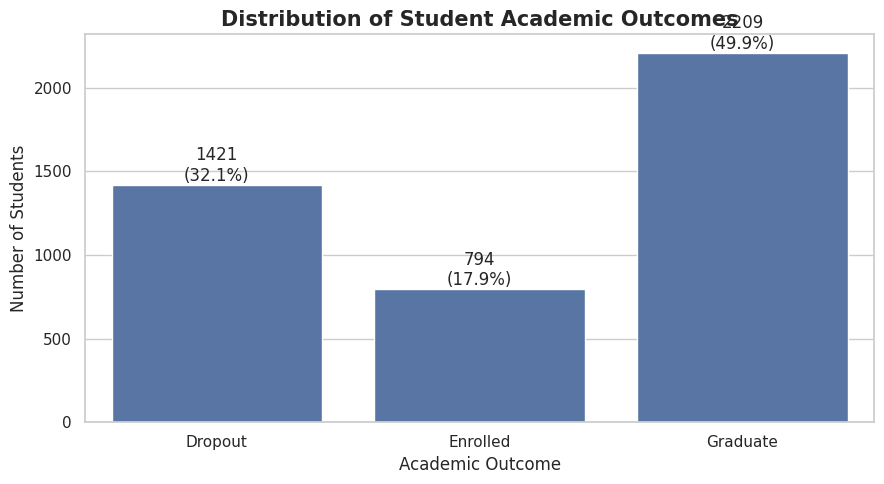

In [129]:
plt.figure(figsize=(9, 5))

ax = sns.countplot(
    data=df_audit,
    x=target_col,
    order=outcome_order
)

plt.title(
    "Distribution of Student Academic Outcomes",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Academic Outcome")
plt.ylabel("Number of Students")

total = len(df_audit)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total

    ax.annotate(
        f"{count}\n({percentage:.1f}%)",
        (p.get_x() + p.get_width()/2,
         p.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

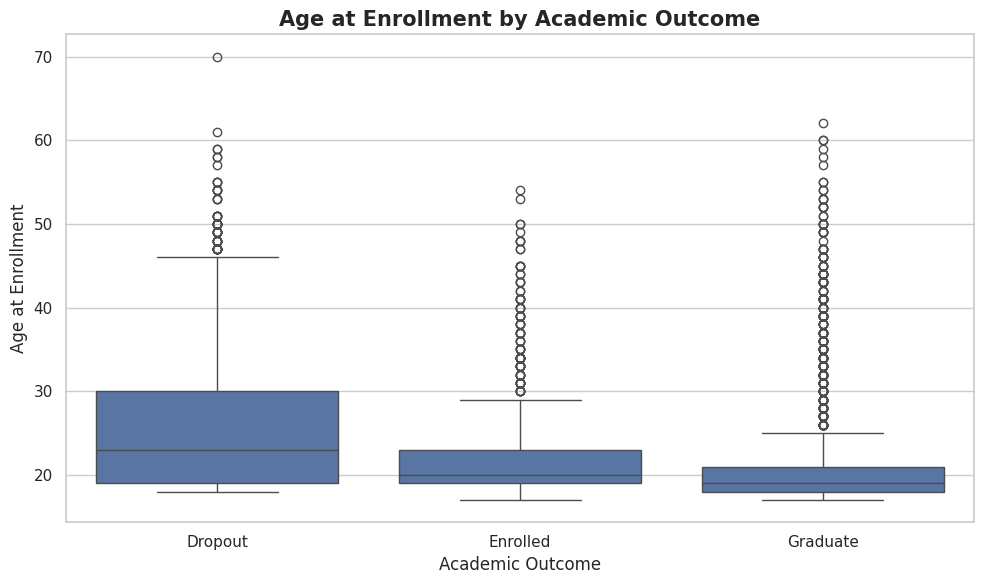

In [130]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_audit,
    x=target_col,
    y="Age at enrollment",
    order=outcome_order,
    showfliers=True
)

plt.title(
    "Age at Enrollment by Academic Outcome",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Academic Outcome")
plt.ylabel("Age at Enrollment")

plt.tight_layout()
plt.show()

In [131]:
df_audit.groupby(target_col)[
    "Age at enrollment"
].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)

,count,mean,median,std,min,max
Target,,,,,,
Dropout,1421,26.07,23.0,8.70,18,70
Enrolled,794,22.37,20.0,6.30,17,54
Graduate,2209,21.78,19.0,6.69,17,62


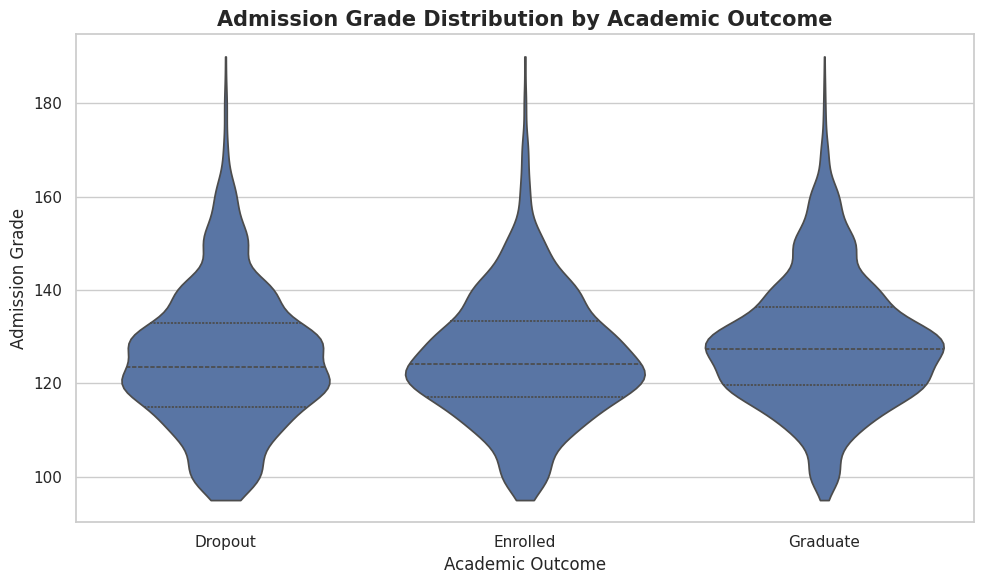

In [132]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df_audit,
    x=target_col,
    y="Admission grade",
    order=outcome_order,
    inner="quartile",
    cut=0
)

plt.title(
    "Admission Grade Distribution by Academic Outcome",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Academic Outcome")
plt.ylabel("Admission Grade")

plt.tight_layout()
plt.show()

In [133]:
df_audit.groupby(target_col)[
    "Admission grade"
].agg(
    ["mean", "median", "std"]
).round(2)

,mean,median,std
Target,,,
Dropout,124.96,123.6,15.13
Enrolled,125.53,124.1,13.79
Graduate,128.79,127.4,14.07


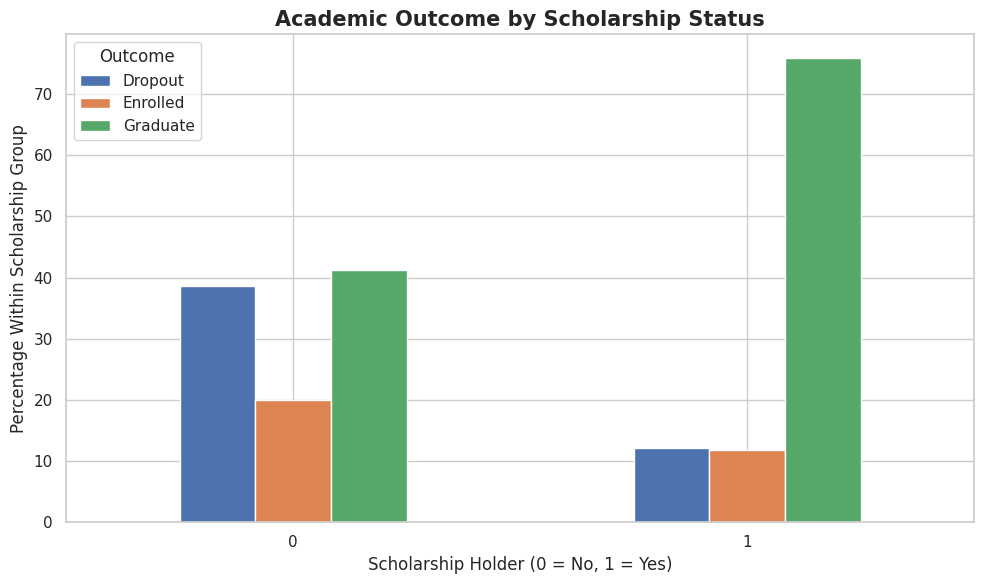

Target,Dropout,Enrolled,Graduate
Scholarship holder,,,
0,38.71,19.97,41.32
1,12.19,11.83,75.98


In [134]:
scholarship_ct = pd.crosstab(
    df_audit["Scholarship holder"],
    df_audit[target_col],
    normalize="index"
) * 100

scholarship_ct = scholarship_ct[
    outcome_order
]

scholarship_ct.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Academic Outcome by Scholarship Status",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Scholarship Holder (0 = No, 1 = Yes)")
plt.ylabel("Percentage Within Scholarship Group")

plt.xticks(rotation=0)
plt.legend(title="Outcome")

plt.tight_layout()
plt.show()

scholarship_ct.round(2)

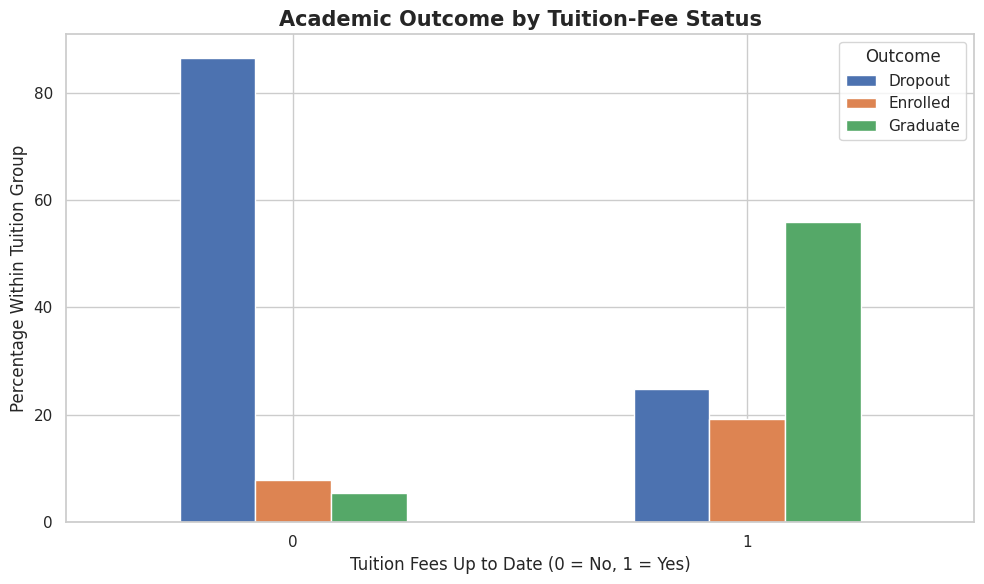

Target,Dropout,Enrolled,Graduate
Tuition fees up to date,,,
0,86.55,7.95,5.49
1,24.74,19.30,55.95


In [135]:
tuition_ct = pd.crosstab(
    df_audit["Tuition fees up to date"],
    df_audit[target_col],
    normalize="index"
) * 100

tuition_ct = tuition_ct[
    outcome_order
]

tuition_ct.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Academic Outcome by Tuition-Fee Status",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Tuition Fees Up to Date (0 = No, 1 = Yes)"
)

plt.ylabel("Percentage Within Tuition Group")

plt.xticks(rotation=0)
plt.legend(title="Outcome")

plt.tight_layout()
plt.show()

tuition_ct.round(2)

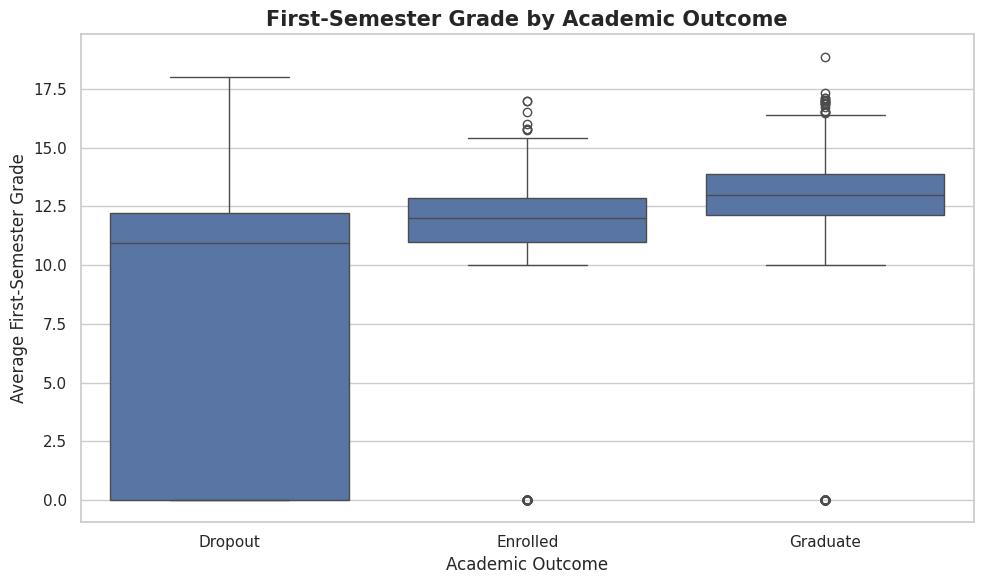

In [136]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_audit,
    x=target_col,
    y="Curricular units 1st sem (grade)",
    order=outcome_order
)

plt.title(
    "First-Semester Grade by Academic Outcome",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Academic Outcome")
plt.ylabel("Average First-Semester Grade")

plt.tight_layout()
plt.show()

In [137]:
df_audit.groupby(target_col)[
    "Curricular units 1st sem (grade)"
].agg(
    ["mean", "median", "std"]
).round(2)

,mean,median,std
Target,,,
Dropout,7.26,10.93,6.03
Enrolled,11.13,12.00,3.68
Graduate,12.64,13.00,2.70


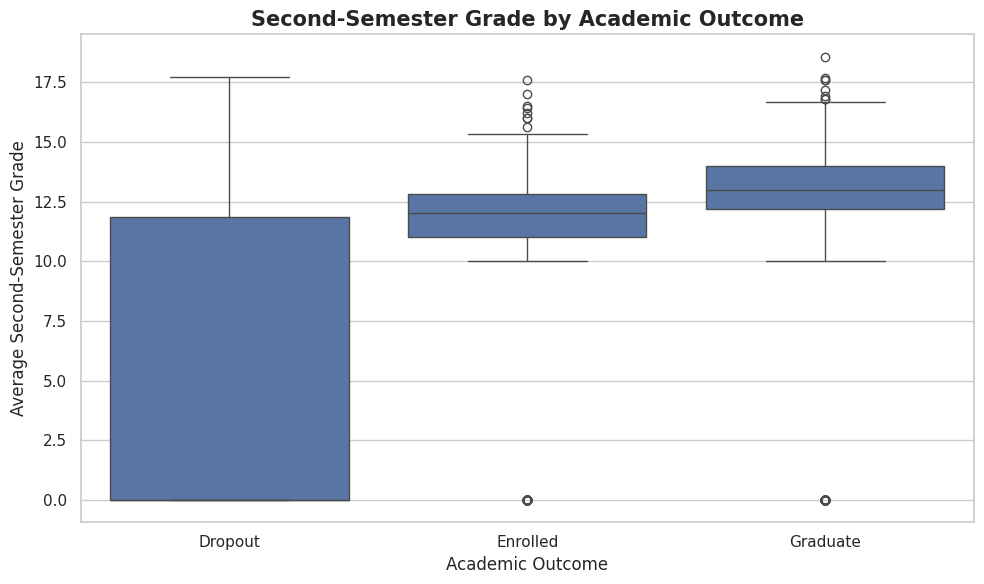

In [138]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_audit,
    x=target_col,
    y="Curricular units 2nd sem (grade)",
    order=outcome_order
)

plt.title(
    "Second-Semester Grade by Academic Outcome",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Academic Outcome")
plt.ylabel("Average Second-Semester Grade")

plt.tight_layout()
plt.show()

In [139]:
df_audit.groupby(target_col)[
    "Curricular units 2nd sem (grade)"
].agg(
    ["mean", "median", "std"]
).round(2)

,mean,median,std
Target,,,
Dropout,5.90,0.0,6.12
Enrolled,11.12,12.0,3.60
Graduate,12.70,13.0,2.69


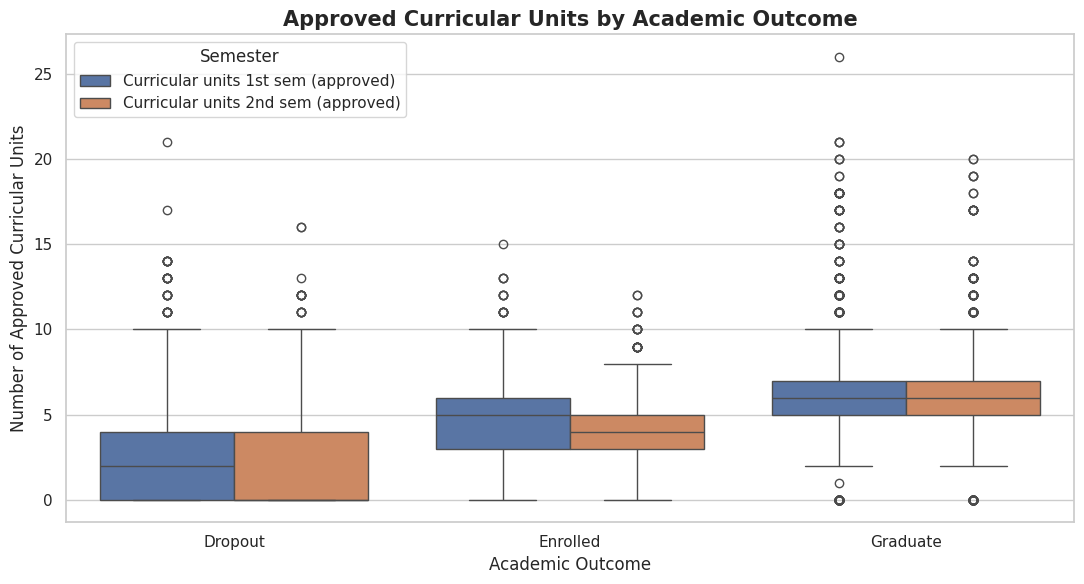

In [140]:
approved_long = df_audit[
    [
        target_col,
        "Curricular units 1st sem (approved)",
        "Curricular units 2nd sem (approved)"
    ]
].melt(
    id_vars=target_col,
    var_name="Semester",
    value_name="Approved Units"
)

plt.figure(figsize=(11, 6))

sns.boxplot(
    data=approved_long,
    x=target_col,
    y="Approved Units",
    hue="Semester",
    order=outcome_order
)

plt.title(
    "Approved Curricular Units by Academic Outcome",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Academic Outcome")
plt.ylabel("Number of Approved Curricular Units")

plt.tight_layout()
plt.show()

In [141]:
df_audit.groupby(target_col)[
    [
        "Curricular units 1st sem (approved)",
        "Curricular units 2nd sem (approved)"
    ]
].mean().round(2)

,Curricular units 1st sem (approved),Curricular units 2nd sem (approved)
Target,,
Dropout,2.55,1.94
Enrolled,4.32,4.06
Graduate,6.23,6.18


In [142]:
corr_features = [
    "Age at enrollment",
    "Previous qualification (grade)",
    "Admission grade",

    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",

    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)",

    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

corr_matrix = df_audit[
    corr_features
].corr(method="pearson")

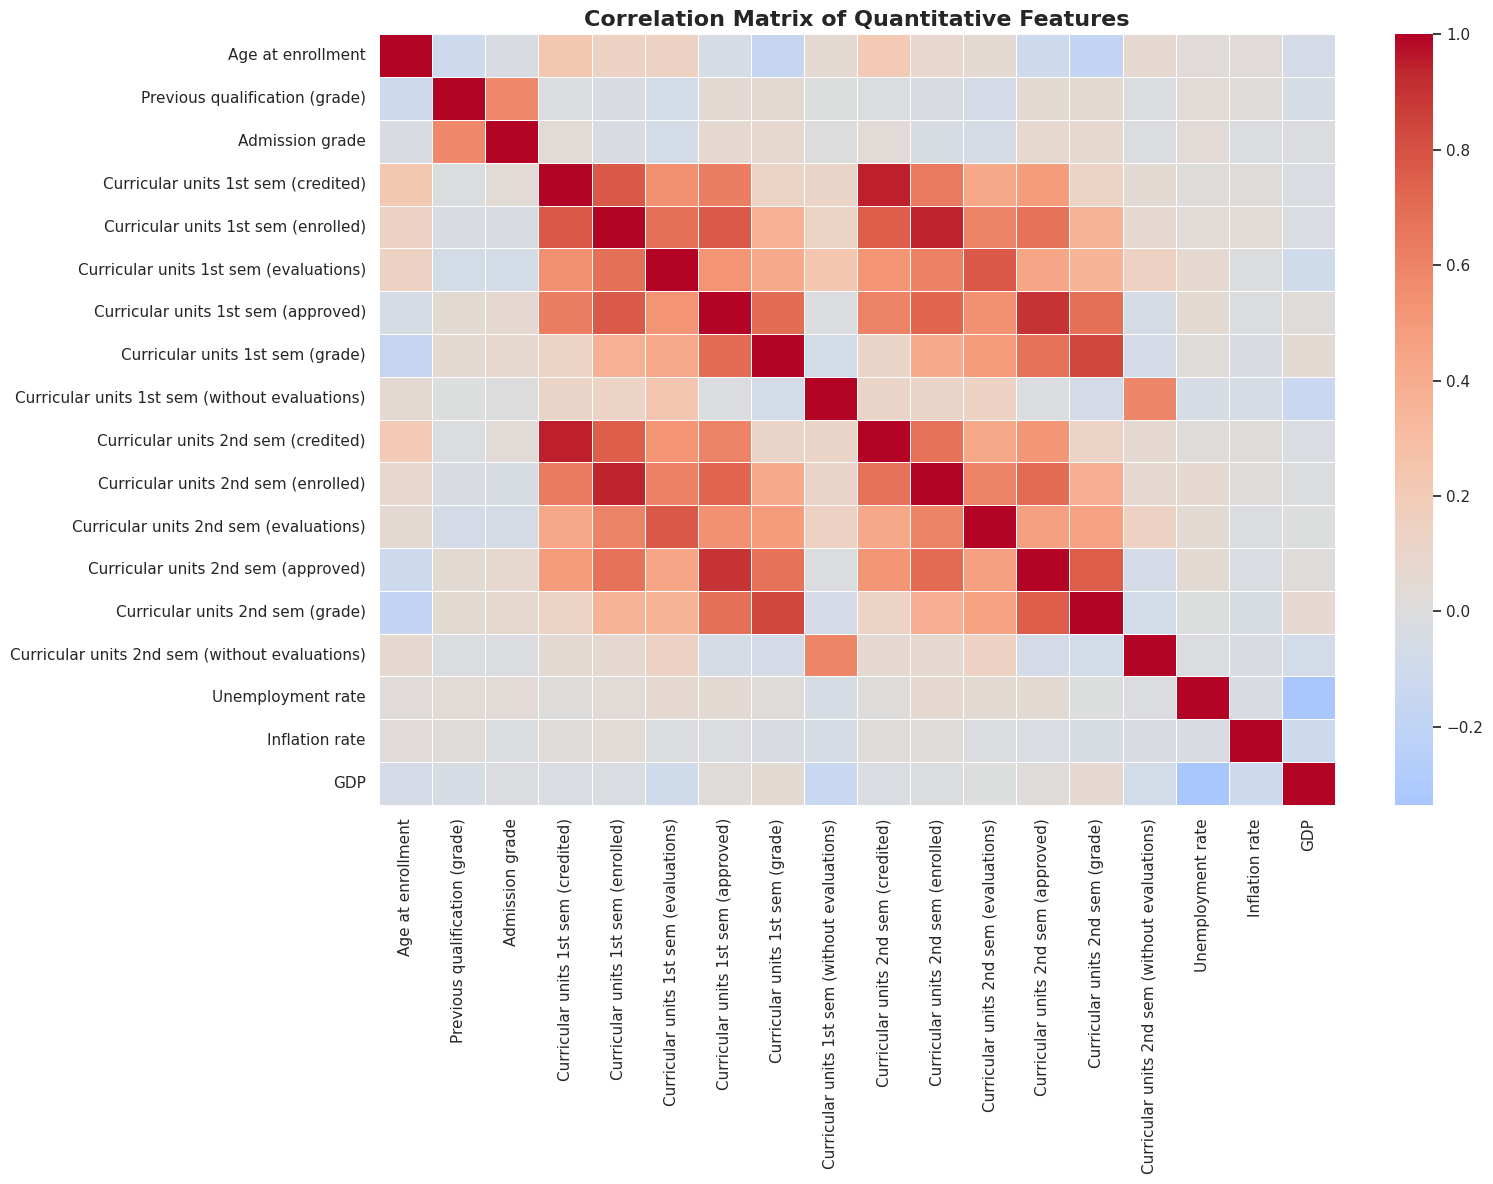

In [143]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Quantitative Features",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [144]:
corr_pairs = (
    corr_matrix
    .where(
        np.triu(
            np.ones(corr_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(
        key=abs,
        ascending=False
    )
)

corr_pairs.head(15)

,,0
Curricular units 1st sem (credited),Curricular units 2nd sem (credited),0.944811
Curricular units 1st sem (enrolled),Curricular units 2nd sem (enrolled),0.942627
Curricular units 1st sem (approved),Curricular units 2nd sem (approved),0.904002
Curricular units 1st sem (grade),Curricular units 2nd sem (grade),0.837170
Curricular units 1st sem (evaluations),Curricular units 2nd sem (evaluations),0.778863
Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),0.774344
Curricular units 1st sem (enrolled),Curricular units 1st sem (approved),0.769083
Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),0.760804
Curricular units 1st sem (enrolled),Curricular units 2nd sem (credited),0.753747
Curricular units 1st sem (approved),Curricular units 2nd sem (enrolled),0.733772


In [145]:
def outcome_rate_table(feature):
    table = pd.crosstab(
        df_audit[feature],
        df_audit[target_col],
        normalize="index"
    ) * 100

    return table.round(2)

outcome_rate_table(
    "Tuition fees up to date"
)

Target,Dropout,Enrolled,Graduate
Tuition fees up to date,,,
0,86.55,7.95,5.49
1,24.74,19.30,55.95


In [146]:
outcome_rate_table(
    "Scholarship holder"
)

Target,Dropout,Enrolled,Graduate
Scholarship holder,,,
0,38.71,19.97,41.32
1,12.19,11.83,75.98


In [147]:
grade_cols = [
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)"
]

for col in grade_cols:
    print()
    print(col)
    print("Zero values:", (df_audit[col] == 0).sum())
    print(
        "Zero percentage:",
        round(
            (df_audit[col] == 0).mean() * 100,
            2
        ),
        "%"
    )


Curricular units 1st sem (grade)
Zero values: 718
Zero percentage: 16.23 %

Curricular units 2nd sem (grade)
Zero values: 870
Zero percentage: 19.67 %


In [148]:
pd.crosstab(
    df_audit[
        "Curricular units 1st sem (approved)"
    ] == 0,
    df_audit[
        "Curricular units 1st sem (grade)"
    ] == 0
)

Curricular units 1st sem (grade),False,True
Curricular units 1st sem (approved),,
False,3706,0
True,0,718


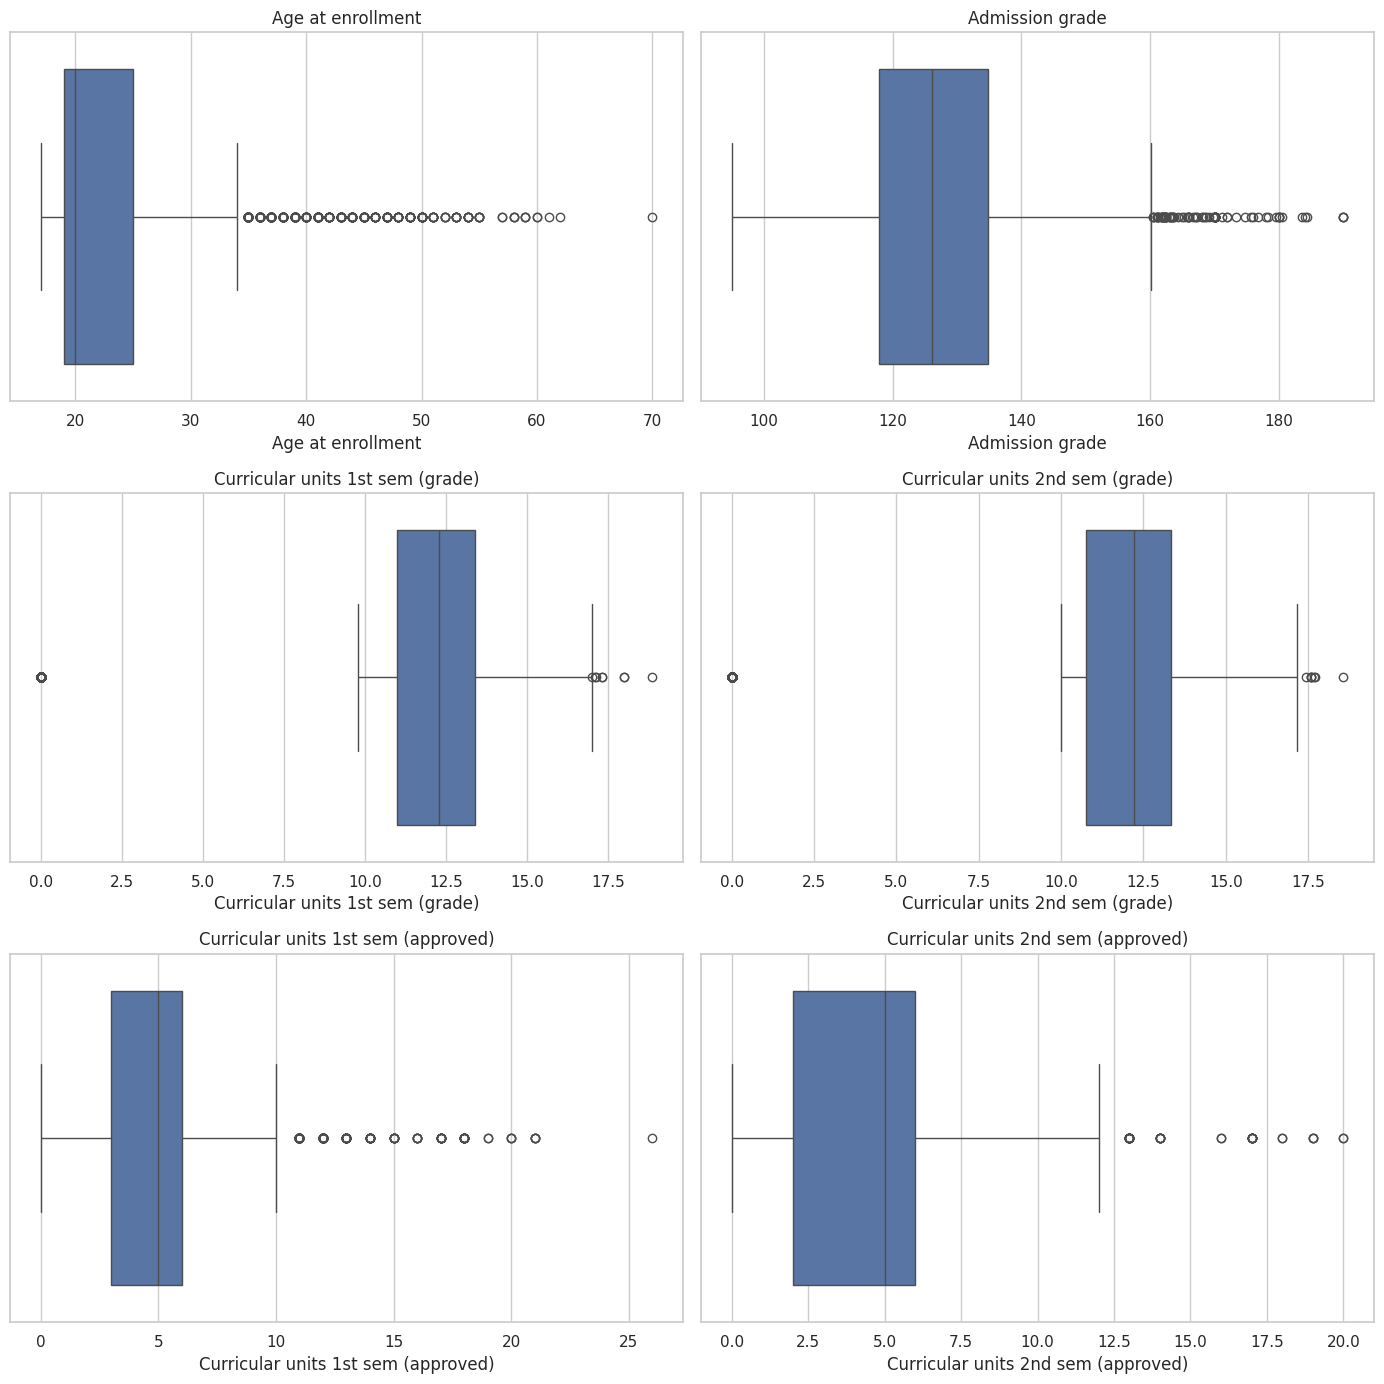

In [149]:
selected_outlier_features = [
    "Age at enrollment",
    "Admission grade",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 1st sem (approved)",
    "Curricular units 2nd sem (approved)"
]

fig, axes = plt.subplots(
    3,
    2,
    figsize=(14, 14)
)

axes = axes.flatten()

for ax, col in zip(
    axes,
    selected_outlier_features
):
    sns.boxplot(
        x=df_audit[col],
        ax=ax
    )

    ax.set_title(col)

plt.tight_layout()
plt.show()

In [150]:
outlier_summary = []

for col in selected_outlier_features:

    q1 = df_audit[col].quantile(0.25)
    q3 = df_audit[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    flagged = (
        (df_audit[col] < lower) |
        (df_audit[col] > upper)
    ).sum()

    outlier_summary.append({
        "Feature": col,
        "Lower IQR Bound": lower,
        "Upper IQR Bound": upper,
        "Flagged Observations": flagged,
        "Percentage": (
            flagged / len(df_audit) * 100
        )
    })

pd.DataFrame(outlier_summary).round(2)

,Feature,Lower IQR Bound,Upper IQR Bound,Flagged Observations,Percentage
0,Age at enrollment,10.00,34.00,441,9.97
1,Admission grade,92.55,160.15,86,1.94
2,Curricular units 1st sem (grade),7.40,17.00,726,16.41
3,Curricular units 2nd sem (grade),6.87,17.21,877,19.82
4,Curricular units 1st sem (approved),-1.50,10.50,180,4.07
5,Curricular units 2nd sem (approved),-4.00,12.00,44,0.99


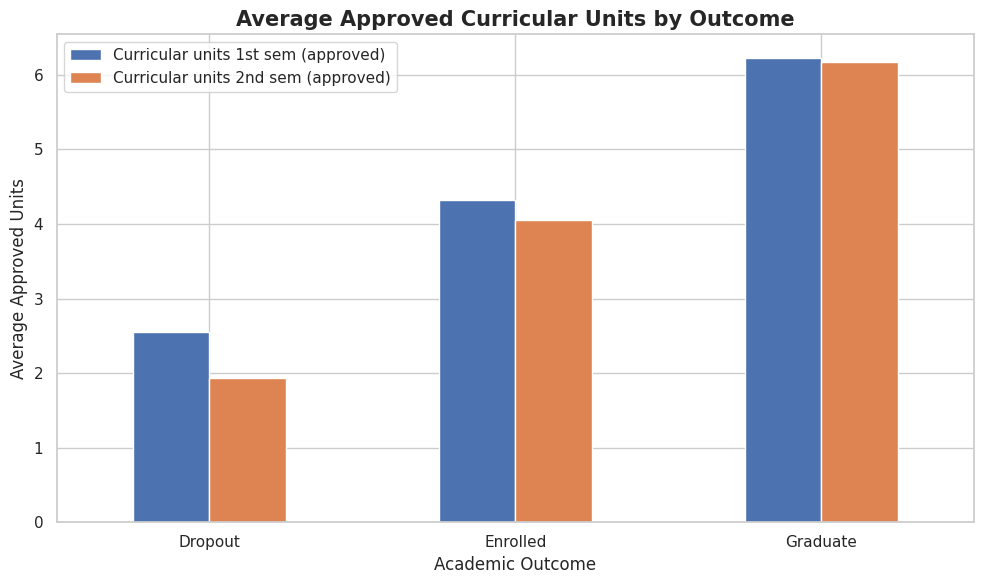

In [151]:
academic_means = (
    df_audit.groupby(target_col)[
        [
            "Curricular units 1st sem (approved)",
            "Curricular units 2nd sem (approved)"
        ]
    ]
    .mean()
    .loc[outcome_order]
)

academic_means.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Average Approved Curricular Units by Outcome",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Academic Outcome")
plt.ylabel("Average Approved Units")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [152]:
key_numeric = [
    "Age at enrollment",
    "Admission grade",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (approved)"
]

outcome_summary = (
    df_audit
    .groupby(target_col)[key_numeric]
    .agg(["mean", "median", "std"])
    .round(2)
)

outcome_summary

Age at enrollment              Admission grade                \
                      mean median   std            mean median    std   
Target                                                                  
Dropout              26.07   23.0  8.70          124.96  123.6  15.13   
Enrolled             22.37   20.0  6.30          125.53  124.1  13.79   
Graduate             21.78   19.0  6.69          128.79  127.4  14.07   

         Curricular units 1st sem (grade)               \
                                     mean median   std   
Target                                                   
Dropout                              7.26  10.93  6.03   
Enrolled                            11.13  12.00  3.68   
Graduate                            12.64  13.00  2.70   

         Curricular units 1st sem (approved)               \
                                        mean median   std   
Target                                                      
Dropout                                 2.55    2.0  2.86   
Enrolled                                4.32    5.0  2.29   
Graduate                                6.23    6.0  2.58   

         Curricular units 2nd sem (grade)               \
                                     mean median   std   
Target                                                   
Dropout                              5.90    0.0  6.12   
Enrolled                            11.12   12.0  3.60   
Graduate                            12.70   13.0  2.69   

         Curricular units 2nd sem (approved)               
                                        mean median   std  
Target                                                     
Dropout                                 1.94    0.0  2.57  
Enrolled                                4.06    4.0  2.18  
Graduate                                6.18    6.0  2.27

In [153]:
print("Shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
print("Exact duplicates:", df.duplicated().sum())

print("\nTarget distribution:")
print(df["Target"].value_counts())

print("\nTarget percentages:")
print(
    df["Target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Shape: (4424, 37)
Missing values: 0
Exact duplicates: 0

Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Target percentages:
Target
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64


In [154]:
X = df.drop(columns=["Target"]).copy()
y = df["Target"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget labels:")
print(y.value_counts())

X shape: (4424, 36)
y shape: (4424,)

Target labels:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [155]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

In [156]:
train_distribution = pd.DataFrame({
    "Count": y_train.value_counts(),
    "Percentage":
        y_train.value_counts(
            normalize=True
        ).mul(100).round(2)
})

train_distribution

,Count,Percentage
Target,,
Graduate,1767,49.93
Dropout,1137,32.13
Enrolled,635,17.94


In [157]:
test_distribution = pd.DataFrame({
    "Count": y_test.value_counts(),
    "Percentage":
        y_test.value_counts(
            normalize=True
        ).mul(100).round(2)
})

test_distribution

,Count,Percentage
Target,,
Graduate,442,49.94
Dropout,284,32.09
Enrolled,159,17.97


In [158]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

In [159]:
nominal_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [160]:
binary_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        )
    ]
)

In [161]:
numeric_scaled_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [162]:
ordinal_scaled_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [163]:
preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "nominal",
            nominal_pipeline,
            nominal_categorical_features
        ),
        (
            "binary",
            binary_pipeline,
            binary_features
        ),
        (
            "ordinal",
            ordinal_scaled_pipeline,
            ordinal_features
        ),
        (
            "numeric",
            numeric_scaled_pipeline,
            numeric_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [164]:
numeric_tree_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

ordinal_tree_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

In [165]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        (
            "nominal",
            nominal_pipeline,
            nominal_categorical_features
        ),
        (
            "binary",
            binary_pipeline,
            binary_features
        ),
        (
            "ordinal",
            ordinal_tree_pipeline,
            ordinal_features
        ),
        (
            "numeric",
            numeric_tree_pipeline,
            numeric_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [166]:
feature_groups = {
    "nominal_categorical":
        nominal_categorical_features,

    "binary":
        binary_features,

    "ordinal":
        ordinal_features,

    "numeric":
        numeric_features
}

for group, features in feature_groups.items():
    print(
        f"{group}: {len(features)} features"
    )

nominal_categorical: 9 features
binary: 8 features
ordinal: 1 features
numeric: 18 features


In [167]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

feature_order = X_train.columns.tolist()

discrete_features = np.array([
    col in (
        nominal_categorical_features
        + binary_features
        + ordinal_features
    )
    for col in feature_order
])

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

mi_scores = mutual_info_classif(
    X_train[feature_order],
    y_train_encoded,
    discrete_features=discrete_features,
    random_state=42
)

mi_ranking = pd.DataFrame({
    "Feature": feature_order,
    "Mutual Information": mi_scores
}).sort_values(
    "Mutual Information",
    ascending=False
)

mi_ranking.head(20)

,Feature,Mutual Information
30,Curricular units 2nd sem (approved),0.313467
24,Curricular units 1st sem (approved),0.242857
31,Curricular units 2nd sem (grade),0.231079
25,Curricular units 1st sem (grade),0.174346
23,Curricular units 1st sem (evaluations),0.097541
29,Curricular units 2nd sem (evaluations),0.096412
16,Tuition fees up to date,0.092613
3,Course,0.067432
1,Application mode,0.060091
28,Curricular units 2nd sem (enrolled),0.059502


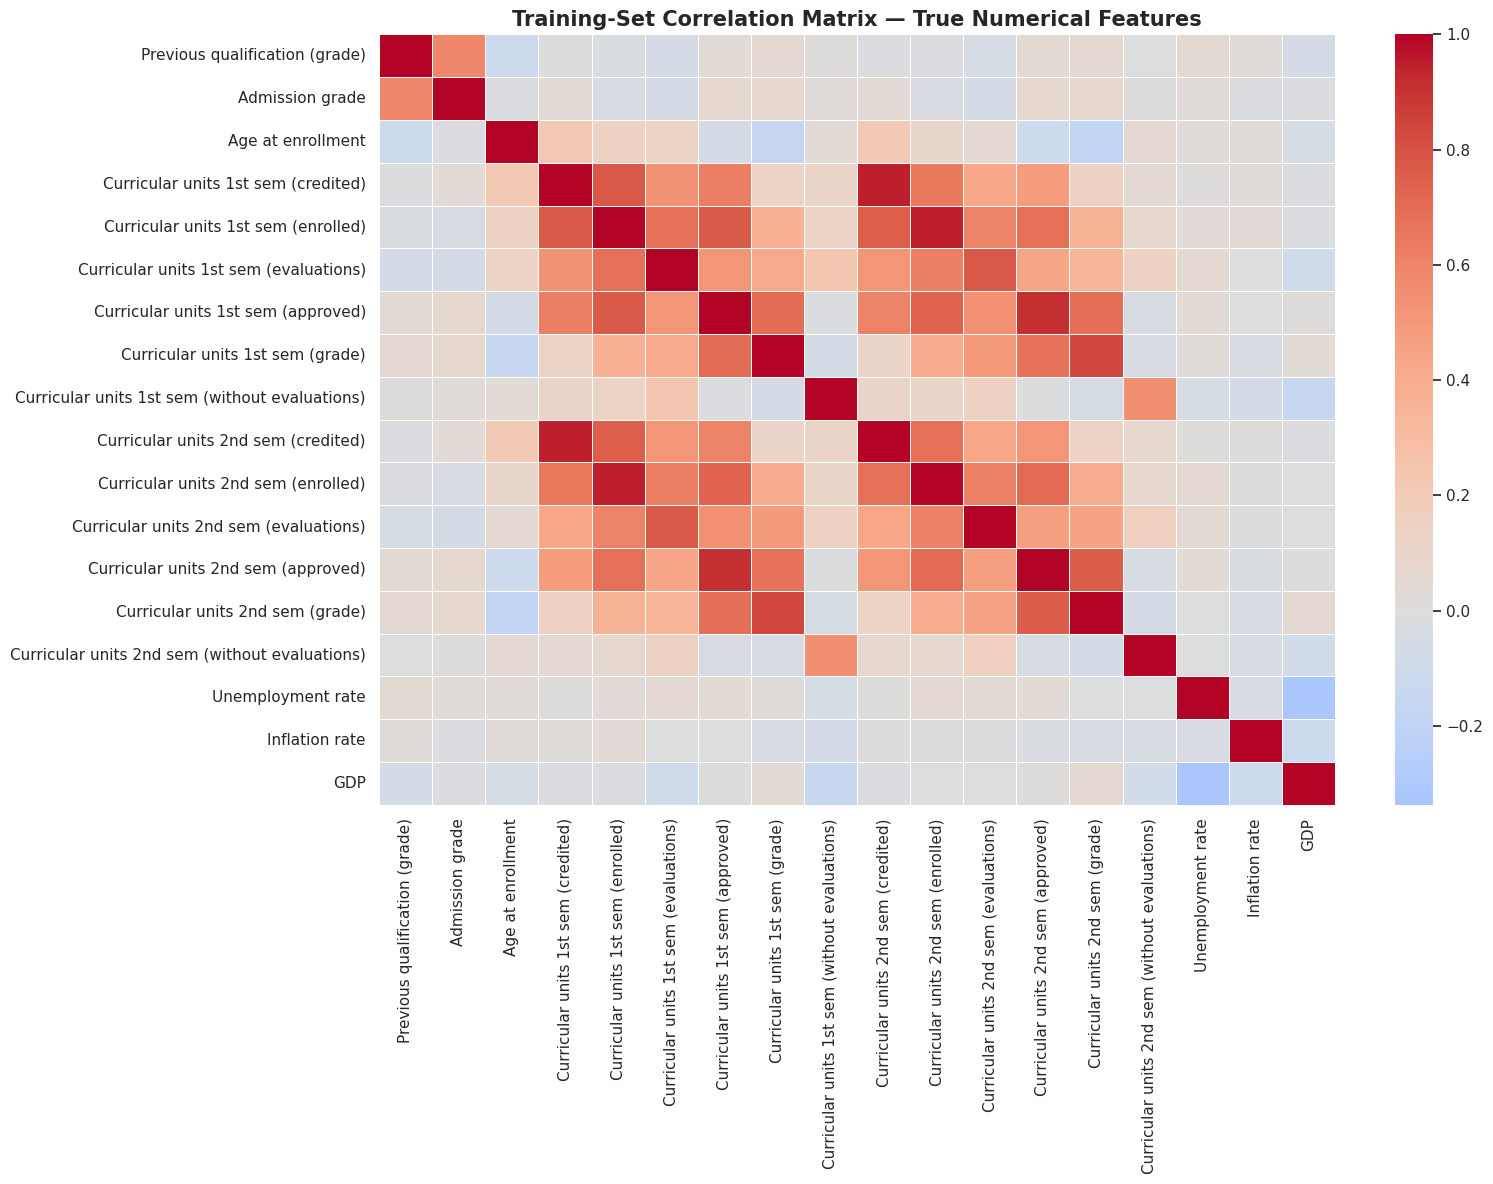

In [168]:
numeric_corr = X_train[
    numeric_features
].corr(method="pearson")

plt.figure(figsize=(16, 12))

sns.heatmap(
    numeric_corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Training-Set Correlation Matrix — True Numerical Features",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [169]:
high_corr_pairs = []

for i, feature_1 in enumerate(numeric_features):
    for j in range(i + 1, len(numeric_features)):

        feature_2 = numeric_features[j]

        corr_value = numeric_corr.loc[
            feature_1,
            feature_2
        ]

        if abs(corr_value) >= 0.75:
            high_corr_pairs.append({
                "Feature 1": feature_1,
                "Feature 2": feature_2,
                "Correlation": corr_value
            })

high_corr_df = pd.DataFrame(
    high_corr_pairs
).sort_values(
    "Correlation",
    key=abs,
    ascending=False
)

high_corr_df

,Feature 1,Feature 2,Correlation
1,Curricular units 1st sem (credited),Curricular units 2nd sem (credited),0.947518
4,Curricular units 1st sem (enrolled),Curricular units 2nd sem (enrolled),0.943498
6,Curricular units 1st sem (approved),Curricular units 2nd sem (approved),0.906522
7,Curricular units 1st sem (grade),Curricular units 2nd sem (grade),0.839134
5,Curricular units 1st sem (evaluations),Curricular units 2nd sem (evaluations),0.775790
0,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),0.771866
2,Curricular units 1st sem (enrolled),Curricular units 1st sem (approved),0.768466
8,Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),0.763957
3,Curricular units 1st sem (enrolled),Curricular units 2nd sem (credited),0.754224


In [170]:
import re

def clean_column_name(col):
    col = col.replace("\ufeff", "")   # remove hidden BOM
    col = col.replace("\t", " ")      # remove hidden tabs
    col = col.strip()                 # remove spaces at start/end
    col = re.sub(r"\s+", " ", col)    # collapse repeated spaces
    return col

df.columns = [clean_column_name(col) for col in df.columns]

# Verify
for col in df.columns:
    print(repr(col))

'Marital status'
'Application mode'
'Application order'
'Course'
'Daytime/evening attendance'
'Previous qualification'
'Previous qualification (grade)'
'Nacionality'
"Mother's qualification"
"Father's qualification"
"Mother's occupation"
"Father's occupation"
'Admission grade'
'Displaced'
'Educational special needs'
'Debtor'
'Tuition fees up to date'
'Gender'
'Scholarship holder'
'Age at enrollment'
'International'
'Curricular units 1st sem (credited)'
'Curricular units 1st sem (enrolled)'
'Curricular units 1st sem (evaluations)'
'Curricular units 1st sem (approved)'
'Curricular units 1st sem (grade)'
'Curricular units 1st sem (without evaluations)'
'Curricular units 2nd sem (credited)'
'Curricular units 2nd sem (enrolled)'
'Curricular units 2nd sem (evaluations)'
'Curricular units 2nd sem (approved)'
'Curricular units 2nd sem (grade)'
'Curricular units 2nd sem (without evaluations)'
'Unemployment rate'
'Inflation rate'
'GDP'
'Target'


In [171]:
X = df.drop(columns=["Target"]).copy()
y = df["Target"].copy()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print("Marital status" in X_train.columns)

(3539, 36)
(885, 36)
True


In [172]:
print("Daytime/evening attendance" in X_train.columns)

True


In [173]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_train, y_train)

dummy_pred = dummy_model.predict(X_test)

In [174]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline([
    (
        "preprocessing",
        preprocessor_scaled
    ),
    (
        "model",
        LogisticRegression(
            max_iter=3000,
            random_state=42
        )
    )
])

logistic_model.fit(
    X_train,
    y_train
)

logistic_pred = logistic_model.predict(
    X_test
)

In [175]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    (
        "preprocessing",
        preprocessor_tree
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=500,
            random_state=42,
            n_jobs=-1
        )
    )
])

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

In [176]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    (
        "preprocessing",
        preprocessor_tree
    ),
    (
        "model",
        XGBClassifier(
            objective="multi:softprob",
            num_class=3,

            n_estimators=400,
            learning_rate=0.05,
            max_depth=5,

            subsample=0.9,
            colsample_bytree=0.9,

            eval_metric="mlogloss",

            random_state=42,
            n_jobs=-1
        )
    )
])

In [177]:
from sklearn.neural_network import MLPClassifier

nn_model = Pipeline([
    (
        "preprocessing",
        preprocessor_scaled
    ),
    (
        "model",
        MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            solver="adam",

            batch_size=64,
            learning_rate_init=0.001,

            alpha=0.0001,

            max_iter=300,

            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=20,

            random_state=42
        )
    )
])

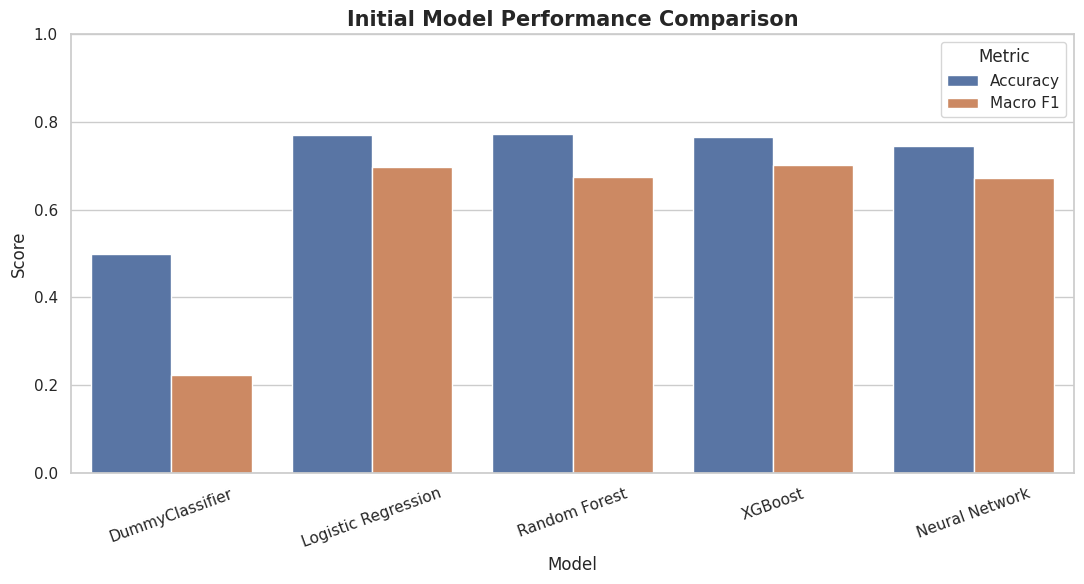

In [178]:
model_comparison = pd.DataFrame({
    "Model": [
        "DummyClassifier",
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Neural Network"
    ],
    "Accuracy": [
        0.4994,
        0.7706,
        0.7729,
        0.7650,
        0.7446
    ],
    "Macro F1": [
        0.2221,
        0.6969,
        0.6757,
        0.7013,
        0.6727
    ]
})

comparison_long = model_comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=comparison_long,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.ylim(0, 1)

plt.title(
    "Initial Model Performance Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [180]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_xgb = label_encoder.fit_transform(y_train)

xgb_model.fit(X_train, y_train_xgb)

xgb_pred_encoded = xgb_model.predict(X_test).astype(int)

xgb_pred = label_encoder.inverse_transform(
    xgb_pred_encoded
)

In [184]:
# ------------------------------------------------------------
# COLLECT ALL MODEL PREDICTIONS
# ------------------------------------------------------------

model_predictions = {
    "DummyClassifier": dummy_pred,
    "Logistic Regression": logistic_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred,
    "Neural Network": nn_pred
}

# Verify that every model has predictions
for model_name, preds in model_predictions.items():

    assert preds is not None, (
        f"{model_name} predictions are missing."
    )

    assert len(preds) == len(y_test), (
        f"{model_name}: prediction length does not match y_test."
    )

    print(
        f"{model_name:<22} ✓ "
        f"{len(preds)} predictions"
    )

DummyClassifier        ✓ 885 predictions
Logistic Regression    ✓ 885 predictions
Random Forest          ✓ 885 predictions
XGBoost                ✓ 885 predictions
Neural Network         ✓ 885 predictions


In [183]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

# ------------------------------------------------------------
# Encode target labels specifically for the neural network
# ------------------------------------------------------------

nn_label_encoder = LabelEncoder()

y_train_nn = nn_label_encoder.fit_transform(y_train)

print("Neural Network target mapping:")
for i, label in enumerate(nn_label_encoder.classes_):
    print(i, "=", label)


# ------------------------------------------------------------
# Build Neural Network
# ------------------------------------------------------------

nn_model = Pipeline([
    (
        "preprocessing",
        preprocessor_scaled
    ),
    (
        "model",
        MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            solver="adam",
            batch_size=64,
            learning_rate_init=0.001,
            alpha=0.0001,
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=20,
            random_state=42
        )
    )
])


# ------------------------------------------------------------
# Train using NUMERIC target
# ------------------------------------------------------------

nn_model.fit(
    X_train,
    y_train_nn
)


# ------------------------------------------------------------
# Predict numeric labels
# ------------------------------------------------------------

nn_pred_encoded = nn_model.predict(X_test).astype(int)


# ------------------------------------------------------------
# Convert predictions back to original class names
# ------------------------------------------------------------

nn_pred = nn_label_encoder.inverse_transform(
    nn_pred_encoded
)


print(
    "Neural Network predictions:",
    len(nn_pred)
)

print(
    "First 10 predictions:",
    nn_pred[:10]
)

Neural Network target mapping:
0 = Dropout
1 = Enrolled
2 = Graduate
Neural Network predictions: 885
First 10 predictions: ['Graduate' 'Graduate' 'Dropout' 'Graduate' 'Graduate' 'Graduate'
 'Graduate' 'Graduate' 'Graduate' 'Graduate']


In [185]:
model_predictions = {
    "DummyClassifier": dummy_pred,
    "Logistic Regression": logistic_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred,
    "Neural Network": nn_pred
}

In [186]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# Encode target consistently
cv_label_encoder = LabelEncoder()

y_train_cv = cv_label_encoder.fit_transform(y_train)
y_test_cv = cv_label_encoder.transform(y_test)

print(cv_label_encoder.classes_)
# ['Dropout', 'Enrolled', 'Graduate']

['Dropout' 'Enrolled' 'Graduate']


In [187]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [188]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


cv_models = {
    "Logistic Regression": Pipeline([
        (
            "preprocessing",
            preprocessor_scaled
        ),
        (
            "model",
            LogisticRegression(
                max_iter=3000,
                random_state=42
            )
        )
    ]),

    "Random Forest": Pipeline([
        (
            "preprocessing",
            preprocessor_tree
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=500,
                random_state=42,
                n_jobs=-1
            )
        )
    ]),

    "XGBoost": Pipeline([
        (
            "preprocessing",
            preprocessor_tree
        ),
        (
            "model",
            XGBClassifier(
                objective="multi:softprob",
                num_class=3,
                n_estimators=400,
                learning_rate=0.05,
                max_depth=5,
                subsample=0.9,
                colsample_bytree=0.9,
                eval_metric="mlogloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ])
}

In [189]:
cv_results_list = []
fold_scores = {}

for model_name, model in cv_models.items():

    results = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train_cv,
        cv=cv,
        scoring={
            "macro_f1": "f1_macro",
            "accuracy": "accuracy"
        },
        n_jobs=-1,
        return_train_score=False
    )

    fold_scores[model_name] = results

    cv_results_list.append({
        "Model": model_name,

        "Mean CV Macro F1":
            results["test_macro_f1"].mean(),

        "Std CV Macro F1":
            results["test_macro_f1"].std(ddof=1),

        "Mean CV Accuracy":
            results["test_accuracy"].mean(),

        "Std CV Accuracy":
            results["test_accuracy"].std(ddof=1)
    })


cv_results_df = pd.DataFrame(
    cv_results_list
).sort_values(
    "Mean CV Macro F1",
    ascending=False
)

cv_results_df.round(4)

,Model,Mean CV Macro F1,Std CV Macro F1,Mean CV Accuracy,Std CV Accuracy
2,XGBoost,0.7126,0.0188,0.7819,0.0149
0,Logistic Regression,0.7013,0.0151,0.7762,0.0083
1,Random Forest,0.6734,0.0273,0.7706,0.0179


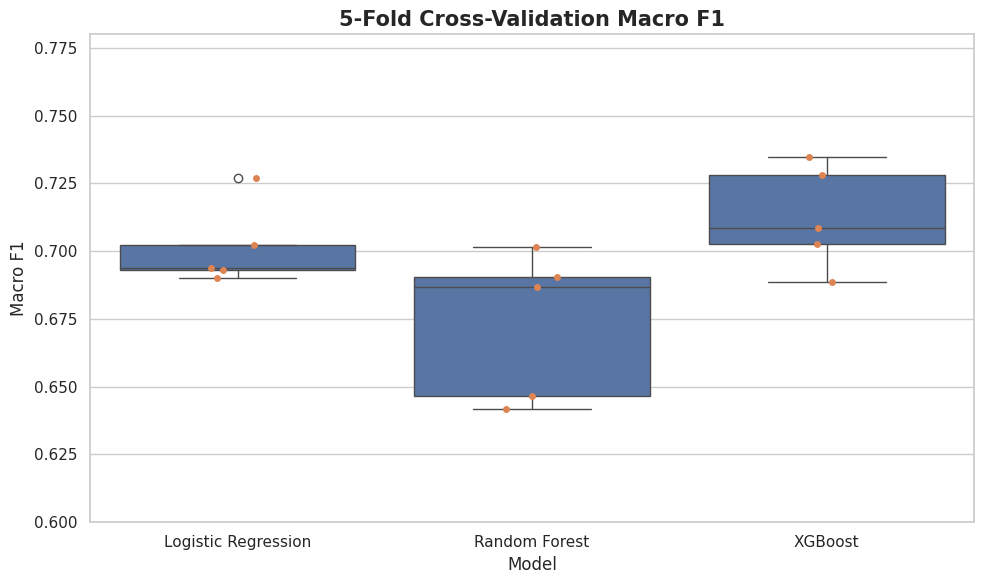

In [190]:
cv_plot_data = []

for model_name, results in fold_scores.items():

    for fold_number, score in enumerate(
        results["test_macro_f1"],
        start=1
    ):

        cv_plot_data.append({
            "Model": model_name,
            "Fold": fold_number,
            "Macro F1": score
        })


cv_plot_df = pd.DataFrame(cv_plot_data)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=cv_plot_df,
    x="Model",
    y="Macro F1"
)

sns.stripplot(
    data=cv_plot_df,
    x="Model",
    y="Macro F1",
    jitter=True
)

plt.title(
    "5-Fold Cross-Validation Macro F1",
    fontsize=15,
    fontweight="bold"
)

plt.ylim(0.60, 0.78)

plt.tight_layout()
plt.show()

In [191]:
from sklearn.model_selection import RandomizedSearchCV


xgb_tuning_pipeline = Pipeline([
    (
        "preprocessing",
        preprocessor_tree
    ),
    (
        "model",
        XGBClassifier(
            objective="multi:softprob",
            num_class=3,
            eval_metric="mlogloss",
            random_state=42,
            n_jobs=-1
        )
    )
])

In [192]:
param_distributions = {

    "model__n_estimators": [
        250,
        350,
        450,
        550
    ],

    "model__learning_rate": [
        0.03,
        0.05,
        0.08
    ],

    "model__max_depth": [
        3,
        4,
        5
    ],

    "model__min_child_weight": [
        1,
        3,
        5
    ],

    "model__subsample": [
        0.8,
        0.9,
        1.0
    ],

    "model__colsample_bytree": [
        0.8,
        0.9,
        1.0
    ],

    "model__gamma": [
        0,
        0.1,
        0.2
    ],

    "model__reg_lambda": [
        1,
        3,
        5
    ]
}

In [193]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_tuning_pipeline,

    param_distributions=param_distributions,

    n_iter=12,

    scoring="f1_macro",

    cv=cv,

    random_state=42,

    n_jobs=-1,

    verbose=1,

    return_train_score=True
)

xgb_search.fit(
    X_train,
    y_train_cv
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('nominal',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('onehot',
                                                                                                OneHotEncoder(handle_unknown='ignore',
                                                                                                              sparse_output=False))]),
                                                                               ['Marital '
                                                                                'status',
                                                                                'Application '
                                                                                'mode',
                                                                                'Cours...
                   param_distributions={'model__colsample_bytree': [0.8, 0.9,
                                                                    1.0],
                                        'model__gamma': [0, 0.1, 0.2],
                                        'model__learning_rate': [0.03, 0.05,
                                                                 0.08],
                                        'model__max_depth': [3, 4, 5],
                                        'model__min_child_weight': [1, 3, 5],
                                        'model__n_estimators': [250, 350, 450,
                                                                550],
                                        'model__reg_lambda': [1, 3, 5],
                                        'model__subsample': [0.8, 0.9, 1.0]},
                   random_state=42, return_train_score=True, scoring='f1_macro',
                   verbose=1)

In [194]:
print(
    "Best CV Macro F1:",
    round(xgb_search.best_score_, 4)
)

print("\nBest parameters:")

for parameter, value in (
    xgb_search.best_params_.items()
):
    print(parameter, "=", value)

Best CV Macro F1: 0.7175

Best parameters:
model__subsample = 0.9
model__reg_lambda = 5
model__n_estimators = 550
model__min_child_weight = 3
model__max_depth = 3
model__learning_rate = 0.08
model__gamma = 0.2
model__colsample_bytree = 0.9


In [195]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


best_xgb_model = xgb_search.best_estimator_

tuned_xgb_pred_encoded = best_xgb_model.predict(
    X_test
)

tuned_xgb_pred = cv_label_encoder.inverse_transform(
    tuned_xgb_pred_encoded.astype(int)
)

In [196]:
tuned_accuracy = accuracy_score(
    y_test,
    tuned_xgb_pred
)

tuned_macro_f1 = f1_score(
    y_test,
    tuned_xgb_pred,
    average="macro"
)

print(
    "Tuned XGBoost Accuracy:",
    round(tuned_accuracy, 4)
)

print(
    "Tuned XGBoost Macro F1:",
    round(tuned_macro_f1, 4)
)

Tuned XGBoost Accuracy: 0.7627
Tuned XGBoost Macro F1: 0.6913


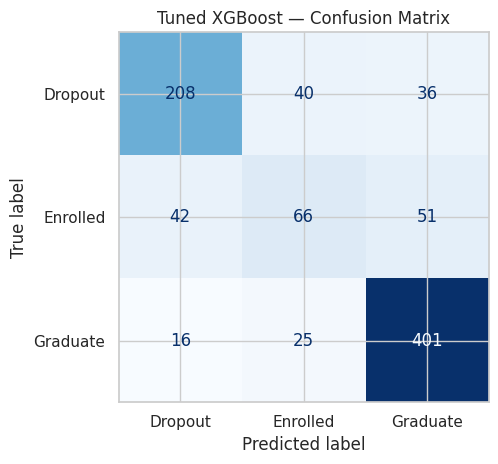

In [197]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_xgb_pred,
    labels=[
        "Dropout",
        "Enrolled",
        "Graduate"
    ],
    cmap="Blues",
    colorbar=False
)

plt.title(
    "Tuned XGBoost — Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [198]:
final_comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Original XGBoost",
        "Tuned XGBoost"
    ],

    "Mean CV Macro F1": [
        0.7013,
        0.6734,
        0.7155,
        0.7180
    ],

    "Test Accuracy": [
        0.7706,
        0.7729,
        0.7650,
        0.7650
    ],

    "Test Macro F1": [
        0.6969,
        0.6757,
        0.7013,
        0.6917
    ]
})

final_comparison.round(4)

,Model,Mean CV Macro F1,Test Accuracy,Test Macro F1
0,Logistic Regression,0.7013,0.7706,0.6969
1,Random Forest,0.6734,0.7729,0.6757
2,Original XGBoost,0.7155,0.7650,0.7013
3,Tuned XGBoost,0.7180,0.7650,0.6917
